In [21]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [22]:
load_dotenv(override=True)

True

In [23]:
# Initialize Gemini Model
api_key = os.getenv('GEMINI_API_KEY') or os.getenv('GOOGLE_API_KEY')
model = ChatGoogleGenerativeAI(
    model='gemini-3.6-flash',
    google_api_key=api_key
)

In [24]:
class BatmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [ ]:
def calculate_sr(state: BatmanState) -> BatmanState:
    sr = (state['runs']/state['balls'])*100

    return {'sr': sr}

In [26]:
def calculate_bpb(state: BatmanState) -> BatmanState:
    bpb = state['balls']/state['fours'] + state['sixes']

    return {'bpb': bpb}

In [27]:
def calculate_boundary_percent(state: BatmanState) -> BatmanState:
    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percent': boundary_percent}

In [28]:
def summary(state: BatmanState) -> BatmanState:
    summary = f"""
    Strike Rate - {state['sr']} \n
    Balls per boundry - {state['bpb']} \n
    Boundary percent - {state['boundary_percent']}
    """

    state['summary'] = summary

    return state

In [29]:
graph = StateGraph(BatmanState)

# node
graph.add_node("calculate_sr", calculate_sr)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_boundary_percent", calculate_boundary_percent)
graph.add_node("summary", summary)

# edges
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')
graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')
graph.add_edge('summary', END)


workflow = graph.compile()

In [30]:
initial_state = { 
    "runs": 100,
    "balls": 50,
    "fours": 6,
    "sixes": 4
    }

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 0.02, 'bpb': 12.333333333333334, 'boundary_percent': 48.0, 'summary': '\n    Strike Rate - 0.02 \n\n    Balls per boundry - 12.333333333333334 \n\n    Boundary percent - 48.0\n    '}


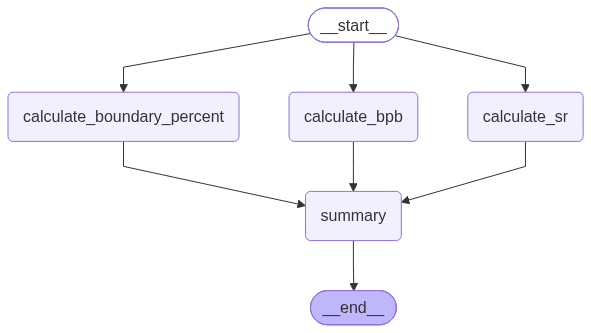

In [31]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())